# Deep Learning Models
## Indian Food Delivery App Sentiment Intelligence System

---
This notebook builds and compares Perceptron and ANN models
for sentiment classification and compares them against ML models.

In [3]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 6.2 MB/s eta 0:00:57
   ---------------------------------------- 1.6/351.2 MB 3.7 MB/s eta 0:01:34
   ---------------------------------------- 2.1/351.2 MB 4.2 MB/s eta 0:01:23
   ---------------------------------------- 3.1/351.2 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 3.9/351.2 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 4.7/351.2 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 5.5/351.2 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 6.0/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 7.1/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 7.9/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 8.7/351.2 MB 3.9 MB/s eta 0:01:29
   - -------------------------------------- 9.7/351.2 MB 3.9 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.72.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
google-api-core 2.29.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.34.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.0 which is incompatible.
proto-plus 1.27.0 requires protobuf<7.0.0,>=3.19.0, but you have protobuf 7.34.0 which is incompatible.
streamlit 1.51.0 requires packaging<26,>=20, but you have packaging 26.0 which is incompat

## 1. Importing Libraries & Data Preparation

Loading processed data and preparing features using
TF-IDF Vectorization and One-Hot Encoding for neural network training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.21.0


In [5]:
df = pd.read_csv(r"C:\Users\Dell\Data_Science_Project\05_NLP_Sentiments_Project\Data\Processed\processed_reviews.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (1459, 9)


In [6]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df['processed_review']).toarray()
y = df['sentiment']

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=3)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data preparation done!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Classes      : {le.classes_}")

Data preparation done!
X_train shape: (1167, 916)
X_test shape : (292, 916)
y_train shape: (1167, 3)
Classes      : ['Negative' 'Neutral' 'Positive']


## 2. Perceptron Model

Perceptron is the simplest form of neural network with a single layer.
It serves as our baseline deep learning model.

- **Architecture:** Input → Output (1 layer only)
- **Activation:** Softmax for multiclass classification
- **Parameters:** 2,751

In [11]:
perceptron = Sequential([
    Dense(3, input_dim=X_train.shape[1],
          activation='softmax')
])

perceptron.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

perceptron.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │         2,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
perceptron_history = perceptron.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9581 - loss: 0.1954 - val_accuracy: 0.8889 - val_loss: 0.3481
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9581 - loss: 0.1934 - val_accuracy: 0.8889 - val_loss: 0.3466
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9581 - loss: 0.1914 - val_accuracy: 0.8889 - val_loss: 0.3450
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9581 - loss: 0.1895 - val_accuracy: 0.8889 - val_loss: 0.3435
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9590 - loss: 0.1876 - val_accuracy: 0.8974 - val_loss: 0.3420
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9619 - loss: 0.1857 - val_accuracy: 0.8974 - val_loss: 0.3403
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9629 - loss: 0.1838 - val_accuracy: 0.8974 - val_loss: 0.3389
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9629 - loss: 0.1820 - val_accuracy: 0.8974 - val_loss:

In [13]:
perceptron_loss, perceptron_acc = perceptron.evaluate(
    X_test, y_test, verbose=0
)
print(f"\nPerceptron Test Accuracy: {perceptron_acc:.4f}")


Perceptron Test Accuracy: 0.8219


## 3. Artificial Neural Network (ANN)

ANN extends Perceptron by adding multiple hidden layers,
allowing it to learn complex non-linear patterns.

- **Architecture:** Input → 256 → 128 → 64 → Output
- **Dropout:** 0.3, 0.3, 0.2 (prevents overfitting)
- **Parameters:** 276,099

In [16]:
ann_model = Sequential([
    Dense(256, input_dim=X_train.shape[1], 
          activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       234,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,099 (1.05 MB)

 Trainable params: 276,099 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6448 - loss: 0.8581 - val_accuracy: 0.6581 - val_loss: 0.7016
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6895 - loss: 0.5503 - val_accuracy: 0.7521 - val_loss: 0.4964
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8705 - loss: 0.3432 - val_accuracy: 0.9231 - val_loss: 0.3439
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9581 - loss: 0.1661 - val_accuracy: 0.9060 - val_loss: 0.2551
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9800 - loss: 0.0657 - val_accuracy: 0.8889 - val_loss: 0.2293
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9924 - loss: 0.0393 - val_accuracy: 0.9231 - val_loss: 0.2837
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9914 - loss: 0.0291 - val_accuracy: 0.9060 - val_loss: 0.2591
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9933 - loss: 0.0274 - val_accuracy: 0.9145 - val_loss

In [18]:
ann_loss, ann_acc = ann_model.evaluate(
    X_test, y_test, verbose=0
)
print(f"\nANN Test Accuracy: {ann_acc:.4f}")


ANN Test Accuracy: 0.8767


## 4. Training Analysis

Analyzing training vs validation accuracy and loss to check
for overfitting or underfitting behavior.

**Observation:** Mild overfitting detected — training accuracy 
reaches 99% while validation stays at 91%. This is expected 
with small datasets of ~1500 samples.

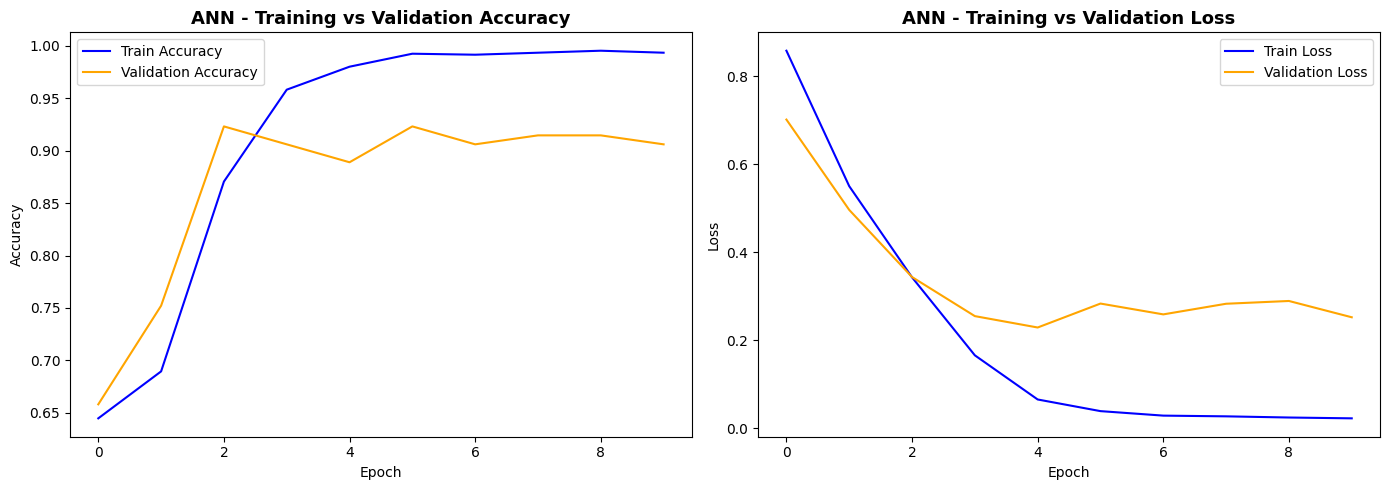

Training history saved successfully!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['accuracy'], 
             label='Train Accuracy', color='blue')
axes[0].plot(ann_history.history['val_accuracy'], 
             label='Validation Accuracy', color='orange')
axes[0].set_title('ANN - Training vs Validation Accuracy',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(ann_history.history['loss'], 
             label='Train Loss', color='blue')
axes[1].plot(ann_history.history['val_loss'], 
             label='Validation Loss', color='orange')
axes[1].set_title('ANN - Training vs Validation Loss',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/ann_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved successfully!")

## 5. Final Model Comparison — ML vs Deep Learning

Comparing all 7 models (5 ML + 2 DL) on accuracy and F1 score
to select the best model for deployment.

In [20]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 
              'Naive Bayes', 'SVM', 'Random Forest',
              'Perceptron', 'ANN'],
    'Accuracy': [0.8699, 0.7363, 0.8664, 
                 0.8973, 0.9110, 0.8219, 0.8767],
    'Type': ['ML', 'ML', 'ML', 'ML', 'ML', 'DL', 'DL']
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print("=" * 55)
print("        FINAL MODEL COMPARISON RESULTS")
print("=" * 55)
print(results_df[['Model', 'Type', 'Accuracy %']].to_string())
print("=" * 55)
print(f"\nBest Model: {results_df.iloc[0]['Model']}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy %']}%")

        FINAL MODEL COMPARISON RESULTS
                 Model Type  Accuracy %
1        Random Forest   ML       91.10
2                  SVM   ML       89.73
3                  ANN   DL       87.67
4  Logistic Regression   ML       86.99
5          Naive Bayes   ML       86.64
6           Perceptron   DL       82.19
7        Decision Tree   ML       73.63

Best Model: Random Forest
Best Accuracy: 91.1%


In [21]:
from matplotlib.patches import Patch

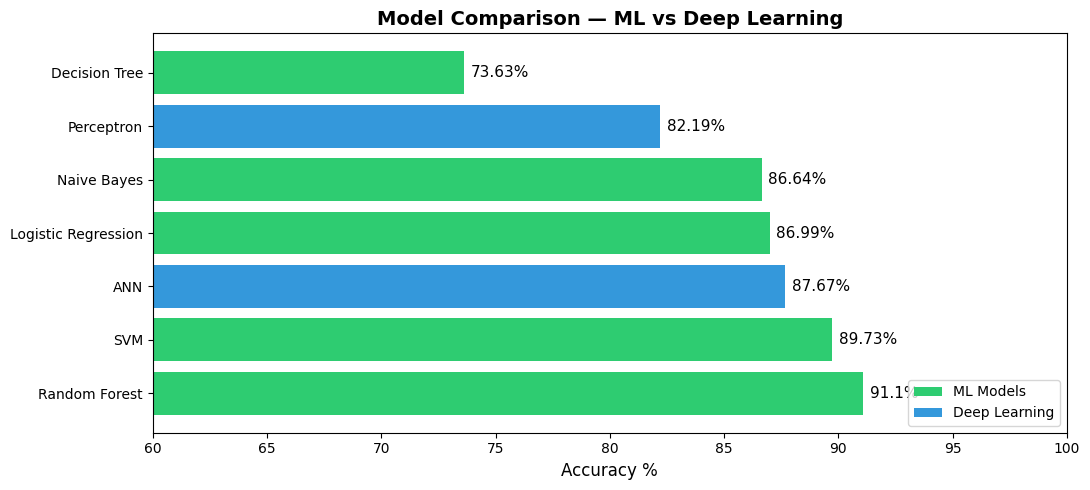

Final comparison chart saved!


In [24]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#2ecc71' if t == 'ML' else '#3498db' 
          for t in results_df['Type']]
bars = ax.barh(results_df['Model'], 
               results_df['Accuracy %'],
               color=colors)
for bar, acc in zip(bars, results_df['Accuracy %']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{acc}%', va='center', fontsize=11)

ax.set_xlabel('Accuracy %', fontsize=12)
ax.set_title('Model Comparison — ML vs Deep Learning',
              fontsize=14, fontweight='bold')
ax.set_xlim(60, 100)

legend_elements = [
    Patch(facecolor='#2ecc71', label='ML Models'),
    Patch(facecolor='#3498db', label='Deep Learning')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Final comparison chart saved!")

## 6. Conclusion & Key Findings

| Model | Type | Accuracy |
|-------|------|----------|
| Random Forest | ML | 91.10% |
| SVM | ML | 89.73% |
| ANN | DL | 87.67% |
| Logistic Regression | ML | 86.99% |
| Naive Bayes | ML | 86.64% |
| Perceptron | DL | 82.19% |
| Decision Tree | ML | 73.63% |

**Key Finding:** Random Forest outperforms all models including ANN
because deep learning requires more data to show its true potential.
For datasets under 5000 samples, traditional ML models often win.

**Best Model:** Random Forest (91.10% accuracy)
